In [ ]:
import pandas as pd
import nltk
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
import json

# Helper functions
def load_tsv(file_path):
    return pd.read_csv(file_path, sep='\t')

def concatenate_and_filter(datasets, filter_column=None, filter_value=None):
    concatenated = pd.concat(datasets)
    if filter_column and filter_value:
        return concatenated[concatenated[filter_column] == filter_value]
    return concatenated

# Load datasets
horoscop_neti = {
    "train": load_tsv("./neti_train.tsv"),
    "test": load_tsv("./neti_test.tsv"),
    "validation": load_tsv("./neti_validation.tsv")
}

vreme = {
    "train": load_tsv("./vreme_train.tsv"),
    "test": load_tsv("./vreme_test.tsv"),
    "validation": load_tsv("./vreme_validation.tsv")
}

# Define model datasets
model_horoscop = pd.concat([horoscop_neti["train"], horoscop_neti["validation"]])
model_vreme = concatenate_and_filter([vreme["train"], vreme["validation"]], 'gender', 'masc')
model_busu = concatenate_and_filter([vreme["train"], vreme["validation"]], 'name', 'Florin Busuioc')
model_horoscop_vreme = pd.concat([model_vreme, model_horoscop])


In [ ]:

# NLTK setup
nltk.download('punkt')
stemmer = SnowballStemmer(language="romanian")

# Process and save the stem dictionaries
def process_and_save_model_data(model_data, file_name):
    stemmed_dict = Counter()
    for sentence in model_data['sentence']:
        words = nltk.word_tokenize(sentence)
        stemmed_words = [stemmer.stem(word.lower()) for word in words if word.isalpha()]
        stemmed_dict.update(stemmed_words)
    with open(file_name, 'w') as file:
        json.dump(dict(stemmed_dict), file, ensure_ascii=False)

# Process each model
process_and_save_model_data(model_horoscop, 'model_horoscop_stems.json')
process_and_save_model_data(model_vreme, 'model_vreme_stems.json')
process_and_save_model_data(model_busu, 'model_busu_stems.json')
process_and_save_model_data(model_horoscop_vreme, 'model_horoscop_vreme_stems.json')

print("Stem dictionaries saved successfully.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Stem dictionaries saved successfully.


# Intersectii dintre datele de test si datele de antrenare

In [ ]:
import pandas as pd
import nltk
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
import json
stemmer = SnowballStemmer(language="romanian")

In [ ]:

# Function to load the stem dictionary from a JSON file
def load_stem_dictionary(json_path):
    with open(json_path, 'r') as file:
        return json.load(file)

# Function to calculate the stems of a given text
def get_stems(text):
    words = nltk.word_tokenize(text)
    return set(stemmer.stem(word.lower()) for word in words if word.isalpha())

# Function to calculate the intersection ratio
def calculate_intersection(stems, dictionary):
    dictionary_set = set(dictionary)
    intersection = stems.intersection(dictionary_set)
    intersection_ratio = len(intersection) / len(stems) if stems else 0
    return intersection, intersection_ratio



In [ ]:
def get_collective_stems(df, column):
    stemmed_counter = Counter()
    for text in df[column]:
        words = nltk.word_tokenize(text)
        stemmed_words = [stemmer.stem(word.lower()) for word in words if word.isalpha()]
        stemmed_counter.update(stemmed_words)
    return set(stemmed_counter)


In [ ]:

# Main function to process test files for each model
def process_models(root_path, model_names, csv_files):
    results = []
    for model_name, path in model_names.items():
        # Load the stem dictionary for the current model
        stem_dict = load_stem_dictionary(f"{model_name}_stems.json")

        # Iterate through each test file associated with the model
        for csv_file in csv_files:
            df = pd.read_csv(f"{root_path}{path}/{csv_file}")
            gt_stems = get_collective_stems(df, 'ground_truth')
            intersection, intersection_ratio = calculate_intersection(gt_stems, stem_dict)

            # Collect results
            results.append({
                "Model": model_name,
                "CSV File": csv_file,
                # "Intersection Count": len(intersection),
                "Intersection Ratio": intersection_ratio,
                "Total Unique Stems in Ground Truth": len(gt_stems),
                "Total Unique Stems in Model": len(stem_dict)
            })

    # Save all results to a single CSV file
    results_df = pd.DataFrame(results)
    results_df.to_csv(f"{root_path}all_model_results.csv", index=False)
    print("All results saved to a single CSV file.")



In [ ]:
root_path = "/content/drive/MyDrive/licenta/outputs/"
model_names = {
    'model_horoscop': 'horoscope_model/horoscope_model_small',
    'model_vreme': 'vreme_model/vreme_model_small',
    'model_busu': 'busu_model/busu_model_small',
    'model_horoscop_vreme': 'vreme_horoscop/vreme_horoscop_small'
    }
csv_files = ['cosmin_stan.csv', 'florin_busuioc.csv', 'iulia_parlea.csv', 'loredana_stefu.csv', 'neti_sandu.csv', 'urania.csv']


In [ ]:
process_models(root_path, model_names, csv_files)

All results saved to a single CSV file.


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
def plot_wer_vs_intersection(csv_path, json_path):
    # Load the CSV file and the JSON dictionary
    df = pd.read_csv(csv_path)
    stem_dict = load_stem_dictionary(json_path)

    intersection_ratios = []
    wer_nocase_values = []

    # Process each row in the dataframe
    for index, row in df.iterrows():
        gt_stems = get_collective_stems(pd.DataFrame([row]), 'ground_truth')
        intersection_ratio = calculate_intersection(gt_stems, stem_dict)
        intersection_ratios.append(intersection_ratio)
        wer_nocase_values.append(row['wer_nocase'])

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.scatter(wer_nocase_values, intersection_ratios, alpha=0.5)
    plt.title('WER NoCase vs Intersection Ratio')
    plt.xlabel('WER NoCase')
    plt.ylabel('Intersection Ratio')
    plt.grid(True)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import nltk
from nltk.stem.snowball import SnowballStemmer
from collections import Counter

# NLTK setup
nltk.download('punkt')
stemmer = SnowballStemmer(language="romanian")

# Function to load the stem dictionary from a JSON file
def load_stem_dictionary(json_path):
    with open(json_path, 'r') as file:
        return json.load(file)

# Function to calculate the intersection ratio
def calculate_intersection(stems, dictionary):
    dictionary_set = set(dictionary)
    intersection = stems & dictionary_set
    intersection_ratio = len(intersection) / len(stems) if stems else 0
    return intersection_ratio

# Function to process a CSV and plot wer_nocase vs intersection_ratio
def plot_wer_vs_intersection(csv_path, json_path):
    # Load the CSV file and the JSON dictionary
    df = pd.read_csv(csv_path)
    stem_dict = load_stem_dictionary(json_path)

    intersection_ratios = []
    wer_nocase_values = []

    # Process each row in the dataframe
    for index, row in df.iterrows():
        # Use a DataFrame slice to handle possible issues with passing wrong data types
        gt_stems = set([stemmer.stem(word.lower()) for word in row['ground_truth'] if word.isalpha()])
        intersection_ratio = calculate_intersection(gt_stems, stem_dict)
        intersection_ratios.append(intersection_ratio)
        wer_nocase_values.append(row['wer_nocase'])

    # Convert to np.array for safe handling in matplotlib
    wer_nocase_values = np.array(wer_nocase_values, dtype=float)
    intersection_ratios = np.array(intersection_ratios, dtype=float)

    print(intersection_ratios)

    # Plotting
    plt.figure(figsize=(5, 5))
    plt.scatter(intersection_ratios, wer_nocase_values, alpha=0.5)
    plt.title('WER NoCase vs Intersection Ratio')
    plt.xlabel('WER NoCase')
    plt.ylabel('Intersection Ratio')
    plt.grid(True)
    plt.show()

# Function to get collective stems from text
def get_collective_stems(df, column):
    stemmed_counter = Counter()
    for text in df[column].iloc[0]:
        words = nltk.word_tokenize(text)
        stemmed_words = [stemmer.stem(word.lower()) for word in words if word.isalpha()]
        stemmed_counter.update(stemmed_words)
    return set(stemmed_counter)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[0.18181818 0.19047619 0.18181818 0.17391304 0.2        0.2
 0.30769231 0.19047619 0.2        0.18181818 0.2        0.16666667
 0.19047619 0.2        0.21052632 0.2        0.21052632 0.19047619
 0.21052632 0.2        0.18181818 0.22222222 0.21052632 0.19047619
 0.21052632 0.17391304 0.18181818 0.21052632 0.2        0.18181818
 0.19047619 0.22222222 0.2        0.19047619 0.19047619 0.21052632
 0.18181818 0.2        0.22222222 0.18181818 0.17391304 0.22222222
 0.2        0.17647059 0.23529412 0.25       0.23529412 0.22222222
 0.2        0.21052632 0.23529412 0.2        0.23529412 0.19047619
 0.21052632 0.18181818 0.23529412 0.23529412 0.22222222 0.23529412
 0.21052632 0.2        0.26666667 0.16666667 0.19047619 0.21052632
 0.22222222 0.21052632 0.25       0.18181818 0.21052632 0.19047619
 0.2        0.22222222 0.22222222 0.22222222 0.2        0.25
 0.18181818 0.2        0.1875     0.21052632 0.2        0.25
 0.2        0.2        0.21052632 0.2        0.21052632 0.19047619
 0.19047619 0.

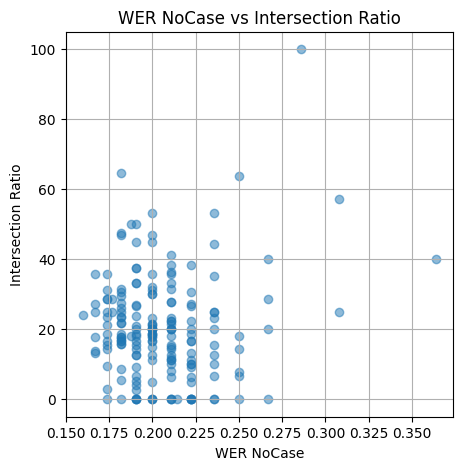

In [ ]:
csv_file_path = "/content/drive/MyDrive/licenta/outputs/horoscope_model/horoscope_model_small/urania.csv"
json_path = "./model_horoscop_stems.json"

# Call the function to plot for the specified file and dictionary
plot_wer_vs_intersection(csv_file_path, json_path)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import nltk
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
# NLTK setup
nltk.download('punkt')
stemmer = SnowballStemmer(language="romanian")
from scipy.stats import kendalltau


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:

# Function to load the stem dictionary from a JSON file
def load_stem_dictionary(json_path):
    with open(json_path, 'r') as file:
        return json.load(file)

In [ ]:
def plot_wer_vs_intersection(csv_path, json_path):
    # Load the CSV file and the JSON dictionary
    file = "loredana_stefu.csv"
    df_tiny = pd.read_csv(f"{csv_path}tiny/{file}")
    df_base = pd.read_csv(f"{csv_path}base/{file}")
    df_small = pd.read_csv(f"{csv_path}small/{file}")

    stem_dict = set(load_stem_dictionary(json_path))

    # intersection_ratios = []
    wer_nocase_values = []
    df_results = pd.DataFrame(columns=['filename', 'com_word_ratio', 'wer_tiny', 'wer_base', 'wer_small'])


    for index, row in df_tiny.iterrows():
        sent = row['ground_truth']
        words = nltk.word_tokenize(sent)
        stemmed_sent = Counter(stemmer.stem(word.lower()) for word in words if word.isalpha())

        set_sent = set(stemmed_sent.elements())
        inter_set = stem_dict & set_sent

        com_word_ratio = len(inter_set) / len(set_sent) if len(set_sent) > 0 else 0

        new_row = {
            'filename': row['filename'],  # Presupunem că există o coloană 'path' în df
            'com_word_ratio': com_word_ratio,
            'wer_tiny': row['wer_nocase'],
            'wer_base': df_base[df_base['filename']==row['filename']]['wer_nocase'].iloc[0],
            'wer_small': df_small[df_small['filename']==row['filename']]['wer_nocase'].iloc[0]
        }
        df_results = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)

    # Salvăm DataFrame-ul de rezultate într-un nou fișier CSV
    output_csv_path = f'/content/drive/MyDrive/licenta/outputs/results_lore_vreme.csv'
    df_results.to_csv(output_csv_path, index=False)

In [ ]:
csv_file_path = "/content/drive/MyDrive/licenta/outputs/vreme_model/vreme_model_"
json_path = "./model_vreme_stems.json"
plot_wer_vs_intersection(csv_file_path, json_path)

In [ ]:
# file = "urania.csv"
# df_tiny = pd.read_csv(f"{csv_file_path}tiny/{file}")
# df_base = pd.read_csv(f"{csv_file_path}base/{file}")

In [ ]:
# print(df_tiny[df_tiny['filename']=='urania-18nov2022_13.wav']['wer_nocase'].iloc[0])

numpy.float64

In [8]:
import pandas as pd
results_file_path =  f'/content/drive/MyDrive/licenta/outputs/results_urania_horoscop.csv'
df_results = pd.read_csv(results_file_path)

In [ ]:
# !pip install jiwer
# from jiwer import wer

In [9]:
df_results

,filename,com_word_ratio,wer_tiny,wer_base,wer_small
0,urania-18nov2022_0.wav,0.647059,76.470588,82.352941,47.058824
1,urania-18nov2022_1.wav,0.588235,100.000000,83.333333,33.333333
2,urania-18nov2022_10.wav,0.866667,58.823529,41.176471,17.647059
3,urania-18nov2022_11.wav,0.823529,42.105263,21.052632,0.000000
4,urania-18nov2022_13.wav,0.941176,50.000000,55.000000,45.000000
...,...,...,...,...,...
179,urania-2iun2023_8.wav,0.730769,46.428571,21.428571,17.857143
180,urania-31mar2023_1.wav,0.647059,94.117647,70.588235,23.529412
181,urania-31mar2023_2.wav,0.692308,73.333333,53.333333,20.000000
182,urania-31mar2023_3.wav,0.750000,58.333333,50.000000,16.666667


Kendall's Tau: -0.19, P-value: 0.0002


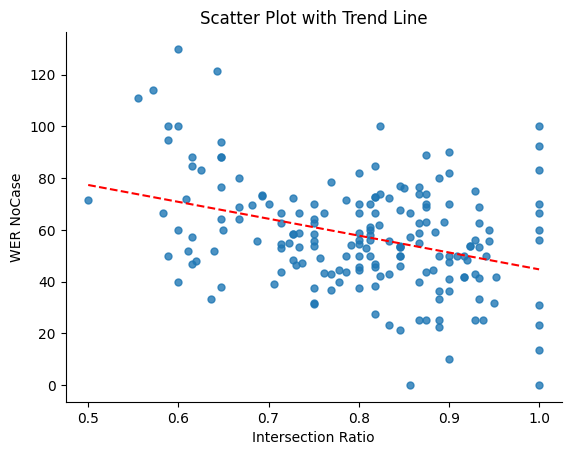

In [ ]:
# import pandas as pd
# from matplotlib import pyplot as plt
# import numpy as np
# from scipy.stats import kendalltau


# # Fit and plot trend line
# z = np.polyfit(df_results['com_word_ratio'], df_results['wer_tiny'], 1)
# p = np.poly1d(z)
# x_trend = np.linspace(df_results['com_word_ratio'].min(), df_results['com_word_ratio'].max(), 100)
# y_trend = p(x_trend)

# df_filtered = df_results[df_results['wer_tiny'] <= 1000]

# # Calculate the trend line for the filtered data
# z = np.polyfit(df_filtered['com_word_ratio'], df_filtered['wer_tiny'], 1)
# p = np.poly1d(z)

# # Generate x values for plotting the trend line
# x_trend = np.linspace(df_filtered['com_word_ratio'].min(), df_filtered['com_word_ratio'].max(), 100)
# y_trend = p(x_trend)

# # Create the scatter plot using the filtered DataFrame
# plt.scatter(df_filtered['com_word_ratio'], df_filtered['wer_tiny'], s=25, alpha=.8, label='Data Points')

# # Plot the trend line
# plt.plot(x_trend, y_trend, "r--", label='Trend Line')

# # Customize plot appearance
# plt.gca().spines[['top', 'right']].set_visible(False)
# plt.title('Scatter Plot with Trend Line')
# plt.xlabel('Intersection Ratio')
# plt.ylabel('WER NoCase')

# # Calculate Kendall's Tau
# tau, p_value = kendalltau(df_results['com_word_ratio'], df_results['wer_tiny'])
# print(f"Kendall's Tau: {tau:.2f}, P-value: {p_value:.4f}")

# # Show plot
# plt.show()


Kendall's Tau: -0.19, P-value: 0.0002


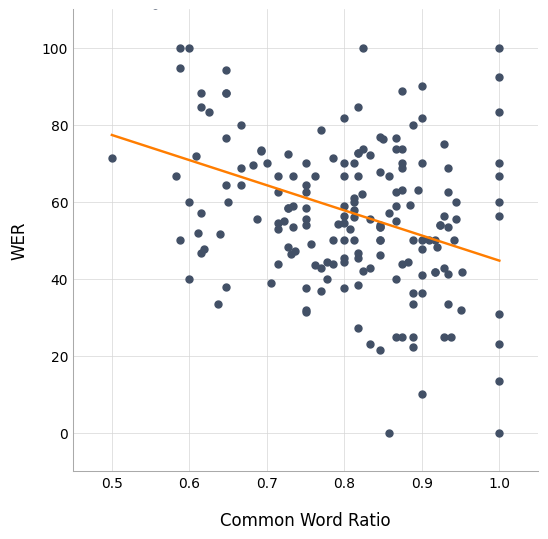

In [ ]:
# import pandas as pd
# from matplotlib import pyplot as plt
# import numpy as np
# from scipy.stats import kendalltau

# # Presupun că df_results este deja definit anterior
# # Exemplu de date (pentru a rula codul, trebuie să ai df_results definit cu aceste coloane)
# # df_results = pd.DataFrame({'com_word_ratio': np.random.rand(100), 'wer_tiny': np.random.rand(100) * 1000})

# # Filtrarea datelor
# df_filtered = df_results[df_results['wer_tiny'] <= 1000]

# # Calcularea liniei de trend pentru datele filtrate
# z = np.polyfit(df_filtered['com_word_ratio'], df_filtered['wer_tiny'], 1)
# p = np.poly1d(z)

# # Generarea valorilor x pentru plotarea liniei de trend
# x_trend = np.linspace(df_filtered['com_word_ratio'].min(), df_filtered['com_word_ratio'].max(), 100)
# y_trend = p(x_trend)


# # Crearea graficului scatter cu DataFrame-ul filtrat
# plt.figure(figsize=(6, 6))
# plt.scatter(df_filtered['com_word_ratio'], df_filtered['wer_tiny'], s=25, alpha=1, color='#425066', label='Data Points', zorder=2)

# # Personalizarea aspectului graficului
# plt.plot(x_trend, y_trend, "-", label='Trend Line', color='#FF7D00', linewidth=1.75) # 909FB6.  E76F51

# plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='#d6d6d6', zorder=0)

# # Setări pentru font
# plt.xlabel('Common Word Ratio', fontsize=12, color='black', labelpad=15)
# plt.ylabel('WER', fontsize=12, color='black', labelpad=10)

# # Setări pentru axe
# ax = plt.gca()
# ax.spines['left'].set_color('#aaaaaa')
# ax.spines['left'].set_linewidth(0.75)
# ax.spines['bottom'].set_color('#aaaaaa')
# ax.spines['bottom'].set_linewidth(0.75)
# ax.spines['right'].set_color('none')
# ax.spines['top'].set_color('none')

# ax.set_xlim(0.45, 1.05)  # Limite pentru axa X cu spațiu adițional
# ax.set_ylim(-10, 110)

# ax.tick_params(axis='both', which='both', length=0)

# tau, p_value = kendalltau(df_results['com_word_ratio'], df_results['wer_tiny'])
# print(f"Kendall's Tau: {tau:.2f}, P-value: {p_value:.4f}")


# resolution_value = 1200
# plt.savefig("urania_horoscop_cwr.png", format="png", dpi=resolution_value)
# # plt.show()

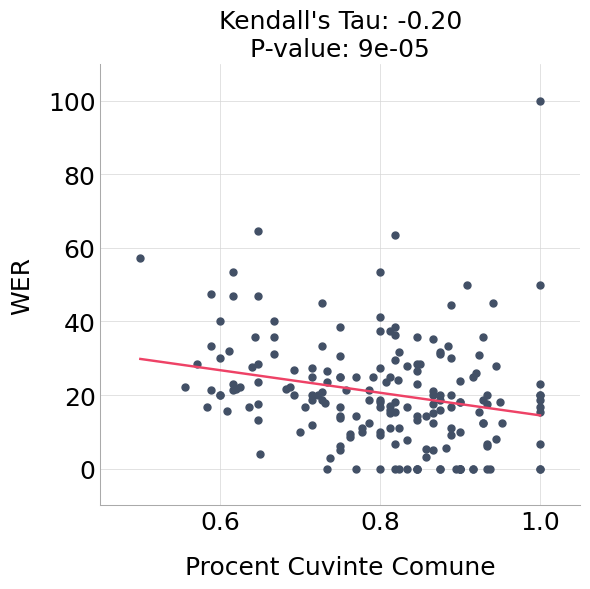

In [12]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import kendalltau

# Functie pentru a crea fiecare grafic
def create_scatter_plot(ax, x, y, title, y_label):
    # Filtrarea datelor
    df_filtered = df_results[df_results[y] <= 100]

    # Calcularea liniei de trend pentru datele filtrate
    z = np.polyfit(df_filtered[x], df_filtered[y], 1)
    p = np.poly1d(z)

    # Generarea valorilor x pentru plotarea liniei de trend
    x_trend = np.linspace(df_filtered[x].min(), df_filtered[x].max(), 100)
    y_trend = p(x_trend)

    # Crearea graficului scatter cu DataFrame-ul filtrat
    ax.scatter(df_filtered[x], df_filtered[y], s=25, alpha=1, color='#425066', label='Data Points', zorder=2) #617494.  425066

    # Personalizarea aspectului graficului
    ax.plot(x_trend, y_trend, "-", label='Trend Line', color='#EE4266', linewidth=1.75)  #993955.  EE4266

    ax.grid(True, which='both', linestyle='-', linewidth=0.5, color='#d6d6d6', zorder=0)

    # Setări pentru font
    ax.set_xlabel('Procent Cuvinte Comune', fontsize=18, color='black', labelpad=15)
    ax.set_ylabel(y_label, fontsize=18, color='black', labelpad=10)

    # Setări pentru axe
    ax.spines['left'].set_color('#aaaaaa')
    ax.spines['left'].set_linewidth(0.75)
    ax.spines['bottom'].set_color('#aaaaaa')
    ax.spines['bottom'].set_linewidth(0.75)
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    ax.set_xlim(0.45, 1.05)  # Limite pentru axa X cu spațiu adițional
    ax.set_ylim(-10, 110)

    ax.tick_params(axis='both', which='both', length=0)

    # Adăugarea titlului
    # ax.set_title(title, fontsize=14, color='black')

    # Calcularea Kendall's Tau
    tau, p_value = kendalltau(df_results[x], df_results[y])
    kendall_text = f"Kendall's Tau: {tau:.2f}\nP-value: {p_value:.0e}"

    ax.set_title(f"{kendall_text}", fontsize=18, color='black') #, weight='bold')
    # ax.text(0.5, 1.05, kendall_text, fontsize=18, color='black', ha='center', va='center', transform=ax.transAxes)


# Crearea figurei și a subgraficele
fig, axs = plt.subplots(1, 1, figsize=(6, 6))

# Crearea celor trei grafice
# create_scatter_plot(axs, 'com_word_ratio', 'wer_tiny', 'Tiny', 'WER')
# create_scatter_plot(axs, 'com_word_ratio', 'wer_base', 'Base', 'WER')
create_scatter_plot(axs, 'com_word_ratio', 'wer_small', 'Small', 'WER')
plt.tick_params(axis='both', which='major', labelsize=18)

# Ajustarea layout-ului pentru a evita suprapunerea elementelor
plt.tight_layout()

# plt.savefig("urania_horoscop_cwr1.png", format="png", dpi=1000)
plt.savefig("ur_hor_small.pdf")
plt.show()


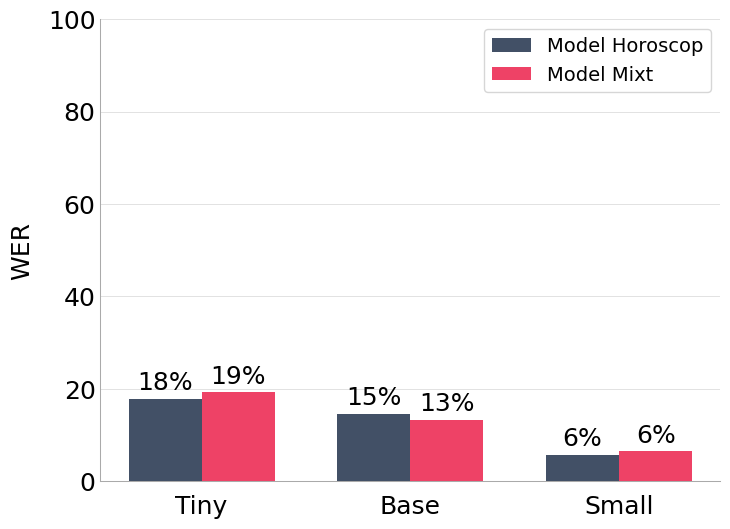

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datele pentru histogramă
categories = ['Tiny', 'Base', 'Small']
# date horoscop

# # neti sandu
nume_model = "Model Horoscop"
whisper_clasic =  [74.00, 61.56, 32.00]
model =   [17.79, 14.63, 5.72]
model_comb = [33.46, 22.42, 10.25]
model_comb2 = [19.18, 13.19,6.42]

# # Urania
# nume_model = "Model Horoscop"
# whisper_clasic = [64.91, 49.38, 25.42]
# model = [57.64, 44.82, 20.55]
# model_comb = [66.60,43.22,22.79]
# model_comb2 = [64.35,40.33,21.80]

# # busu
# nume_model = "Model Vreme"
# whisper_clasic = [69.96, 52.45, 32.76]
# model = [6.95, 5.52, 3.30]
# model_comb = [7.28, 5.59, 2.89]
# model_comb2 = [20.95,13.30,5.53]

# #cosm stan
# nume_model = "Model Vreme"
# whisper_clasic = [68.16, 55.67, 31.69]
# model = [7.56, 6.41, 4.51]
# model_comb = [11.04,8.12,5.43]
# model_comb2 = [25.09, 12.53, 5.98]

# # parlea
# nume_model = "Model Vreme"
# whisper_clasic = [68.64, 55.51, 33.67]
# model = [11.98, 10.35, 4.19]
# model_comb = [12.97,9.40,3.55]
# model_comb2 = [28.99, 19.01,6.78]

# #lore
# nume_model = "Model Vreme"
# whisper_clasic = [66.78, 50.65, 29.40]
# model = [27.55, 28.81, 10.92]
# model_comb = [28.29,20.58,11.36]
# model_comb2 = [37.82,25.85,11.25]



# Setarea pozițiilor pe axa X
x = np.arange(len(categories))  # Pozițiile de pe axa X
width = 0.35  # Lățimea barelor

fig, ax = plt.subplots(figsize=(8, 6))

# Adăugarea barelor pentru Whisper clasic și Model Horoscop
bars1 = ax.bar(x - width/2, model, width, label=nume_model, color='#425066', zorder=3)
bars2 = ax.bar(x + width/2, model_comb2, width, label="Model Mixt", color='#EE4266', zorder=3) #A9B5C7.  EE4266
# # bars3 cu model_comb , nuanta #EE4266

# Adăugarea barelor pentru Whisper clasic, Model Horoscop și Model Comb
# bars1 = ax.bar(x - width, whisper_clasic, width, label='Whisper Clasic', color='#425066', zorder=3)
# bars2 = ax.bar(x, model, width, label=nume_model, color='#A9B5C7', zorder=3)
# bars3 = ax.bar(x + width, model_comb3, width, label='Model Combinat', color='#EE4266', zorder=3)


# Adăugarea titlurilor și etichetelor
ax.set_ylabel('WER', fontsize=18, color='black', labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(categories)

# Setarea limitelor axei Y
ax.set_ylim(0, 100)

# Adăugarea gridului și personalizarea axelor
ax.grid(True, which='both', axis="y", linestyle='-', linewidth=0.5, color='#d6d6d6', zorder=0)
ax.spines['left'].set_color('#aaaaaa')
ax.spines['left'].set_linewidth(0.75)
ax.spines['bottom'].set_color('#aaaaaa')
ax.spines['bottom'].set_linewidth(0.75)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')



# Adăugarea valorilor procentuale deasupra barelor
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points", ha='center', va='bottom', color='black', fontsize=18)

add_labels(bars1)
add_labels(bars2)
# add_labels(bars3)
ax.legend(fontsize=14)

ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', pad=10)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.savefig("ceva.pdf")

# Afișarea graficului
plt.show()